In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from config import LABEL_DIR, IMAGE_DIR

from skimage.morphology import skeletonize
from monai.transforms import LoadImage
import numpy as np

loader = LoadImage(image_only=True)

case = "PanTS_00000086"
vessel_path = f"{LABEL_DIR}/{case}/segmentations/veins.nii.gz"

vessel = loader(vessel_path).numpy()
vessel_binary = (vessel > 0.5).astype(np.uint8)

centreline = skeletonize(vessel_binary)

print(f"Vessel non-zero voxels: {np.count_nonzero(vessel_binary)}")
print(f"Centreline non-zero voxels: {np.count_nonzero(centreline)}")

Vessel non-zero voxels: 27273
Centreline non-zero voxels: 600


In [46]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
label_derivation_path = project_root / "src" / "label_derivation"
sys.path.append(str(label_derivation_path))

from angle_quantify import quantify_angles, ordered_centerline
from extract_centerline import keep_lcc

In [3]:
from monai.transforms import LoadImage
import numpy as np

loader = LoadImage(image_only=True)

case = "PanTS_00000086"
seg_path = f"{LABEL_DIR}/{case}/segmentations"

vessel = loader(f"{seg_path}/veins.nii.gz").numpy()
lesion = loader(f"{seg_path}/pancreatic_lesion.nii.gz").numpy()

vessel_binary = (vessel > 0.5).astype(np.uint8)
lesion_binary = (lesion > 0.5).astype(np.uint8)

from skimage.morphology import skeletonize
centreline = skeletonize(vessel_binary).astype(np.uint8)

print(f"Vessel voxels: {np.count_nonzero(vessel_binary)}")
print(f"Lesion voxels: {np.count_nonzero(lesion_binary)}")
print(f"Centreline voxels: {np.count_nonzero(centreline)}")
print(f"Overlap (lesion + vessel): {np.count_nonzero(vessel_binary & lesion_binary)}")

Vessel voxels: 27273
Lesion voxels: 6556
Centreline voxels: 600
Overlap (lesion + vessel): 150


In [ ]:
from pathlib import Path
import nibabel as nib
import numpy as np

case = "PanTS_00000086"
seg_path = f"{LABEL_DIR}/{case}/segmentations"

project_root = Path("..").resolve()
centreline_out_dir = project_root / "outputs" / "centrelines" / case
angle_out_dir = project_root / "outputs" / "angles" / case

centreline_out_dir.mkdir(parents=True, exist_ok=True)
angle_out_dir.mkdir(parents=True, exist_ok=True)

vessel_nii = nib.load(f"{seg_path}/veins.nii.gz")

centreline_path = centreline_out_dir / "veins_centreline.nii.gz"
centreline_nii = nib.Nifti1Image(
    centreline.astype(np.uint8),
    vessel_nii.affine,
    vessel_nii.header
)
nib.save(centreline_nii, str(centreline_path))
print(f"Centreline saved to: {centreline_path}")

max_angle = quantify_angles(
    vessel_path=Path(f"{seg_path}/veins.nii.gz"),
    tumor_path=Path(f"{seg_path}/pancreatic_lesion.nii.gz"),
    centerline_path=centreline_path,
    out_dir=angle_out_dir,
    save_png=False,
    overlap_ratio=0.1
)

print(f"Maximum encasement angle: {max_angle:.2f} degrees")
print(f"Angle CSV saved to: {angle_out_dir / 'angles.csv'}")

Centreline saved to: /Users/francescad/Msc_Computer_Science/Dissertation/msc_thesis/outputs/centrelines/PanTS_00000086/veins_centreline.nii.gz
Maximum encasement angle: 0.00 degrees
Angle CSV saved to: /Users/francescad/Msc_Computer_Science/Dissertation/msc_thesis/outputs/angles/PanTS_00000086/angles.csv


# NOTES:
Why is the angle computation returning 0???

In [ ]:
from angle_quantify import local_frames, plane_grid, reslice, analyze_slice
import numpy as np

vessel_binary = (loader(f"{seg_path}/veins.nii.gz").numpy() > 0.5).astype(np.uint8)
lesion_binary = (loader(f"{seg_path}/pancreatic_lesion.nii.gz").numpy() > 0.5).astype(np.uint8)

from skimage.morphology import skeletonize
centreline = skeletonize(vessel_binary).astype(np.uint8)

overlap_coords = np.argwhere((vessel_binary & lesion_binary) > 0)
print(f"3D overlap coordinates (first 5):")
print(overlap_coords[:5])
print(f"Total overlap voxels: {len(overlap_coords)}")

centreline_coords = np.argwhere(centreline > 0)
print(f"\nCentreline coordinates near overlap (first 5):")
print(centreline_coords[:5])

3D overlap coordinates (first 5):
[[219 226  37]
 [219 226  38]
 [220 225  37]
 [220 225  38]
 [220 226  35]]
Total overlap voxels: 150

Centreline coordinates near overlap (first 5):
[[ 94 125  51]
 [ 94 126  51]
 [ 95 127  52]
 [ 96 128  52]
 [ 96 129  52]]


# NOTES:
- The overlap coordinates and the centreline coordinates are from different regions of the volume.
- This could be a resampling issue.
- The physical coordinates don't match between the centreline computation and the angle computation.


In [ ]:
from monai.transforms import LoadImage, Spacing
from monai.data import MetaTensor
import numpy as np
import torch

loader = LoadImage(image_only=False)

def load_and_resample(path, mode="nearest"):
    img, meta = loader(path)
    # resampled to 1x1x1mm
    spacing_transform = Spacing(pixdim=(1.0, 1.0, 1.0), mode=mode)
    img_resampled = spacing_transform(img.unsqueeze(0)).squeeze(0)
    return img_resampled.numpy()

case = "PanTS_00000086"
seg_path = f"{LABEL_DIR}/{case}/segmentations"

vessel = load_and_resample(f"{seg_path}/veins.nii.gz")
lesion = load_and_resample(f"{seg_path}/pancreatic_lesion.nii.gz")

vessel_binary = (vessel > 0.5).astype(np.uint8)
lesion_binary = (lesion > 0.5).astype(np.uint8)

overlap = np.count_nonzero(vessel_binary & lesion_binary)
print(f"Vessel voxels after resampling: {np.count_nonzero(vessel_binary)}")
print(f"Lesion voxels after resampling: {np.count_nonzero(lesion_binary)}")
print(f"Overlap after resampling: {overlap}")

from skimage.morphology import skeletonize
centreline = skeletonize(vessel_binary).astype(np.uint8)

overlap_coords = np.argwhere((vessel_binary & lesion_binary) > 0)
centreline_coords = np.argwhere(centreline > 0)

print(f"\nOverlap coordinates (first 5):")
print(overlap_coords[:5])
print(f"\nCentreline coordinates (first 5):")
print(centreline_coords[:5])

Vessel voxels after resampling: 33417
Lesion voxels after resampling: 8073
Overlap after resampling: 192

Overlap coordinates (first 5):
[[154 158  92]
 [154 158  93]
 [154 158  94]
 [154 158  95]
 [154 158  96]]

Centreline coordinates (first 5):
[[ 66  88 127]
 [ 66  89 128]
 [ 67  90 129]
 [ 68  91 130]
 [ 68  92 130]]


- The vein mask has multiple disconnected components and the centreline is being extracted from the wrong component — one that is far from the tumour.

## Check of the vessel components

In [ ]:
from scipy import ndimage as ndi

labeled, n_components = ndi.label(vessel_binary,
                                   structure=np.ones((3,3,3), dtype=np.uint8))

print(f"Number of connected components in vessel mask: {n_components}")

for i in range(1, n_components + 1):
    component_size = np.count_nonzero(labeled == i)

    component_mask = (labeled == i).astype(np.uint8)
    component_overlap = np.count_nonzero(component_mask & lesion_binary)

    print(f"Component {i}: {component_size} voxels, overlap with lesion: {component_overlap}")

Number of connected components in vessel mask: 7
Component 1: 32864 voxels, overlap with lesion: 192
Component 2: 117 voxels, overlap with lesion: 0
Component 3: 8 voxels, overlap with lesion: 0
Component 4: 4 voxels, overlap with lesion: 0
Component 5: 21 voxels, overlap with lesion: 0
Component 6: 388 voxels, overlap with lesion: 0
Component 7: 15 voxels, overlap with lesion: 0


- The vein mask is not one continuous structure. 
- It has 7 separate disconnected pieces

In [ ]:
largest_component = (labeled == 1).astype(np.uint8)

print(f"Largest component voxels: {np.count_nonzero(largest_component)}")
print(f"Overlap with lesion: {np.count_nonzero(largest_component & lesion_binary)}")

# Extract centreline from largest component only
centreline = skeletonize(largest_component).astype(np.uint8)
centreline_coords = np.argwhere(centreline > 0)
overlap_coords = np.argwhere((largest_component & lesion_binary) > 0)

print(f"\nCentreline voxels: {np.count_nonzero(centreline)}")
print(f"\nOverlap coordinates (first 5):")
print(overlap_coords[:5])
print(f"\nCentreline coordinates (first 5):")
print(centreline_coords[:5])

Largest component voxels: 32864
Overlap with lesion: 192

Centreline voxels: 455

Overlap coordinates (first 5):
[[154 158  92]
 [154 158  93]
 [154 158  94]
 [154 158  95]
 [154 158  96]]

Centreline coordinates (first 5):
[[ 66  88 127]
 [ 66  89 128]
 [ 67  90 129]
 [ 68  91 130]
 [ 68  92 130]]


In [ ]:
# Check the full range of centreline coordinates
print(f"Centreline z range: {centreline_coords[:,0].min()} to {centreline_coords[:,0].max()}")
print(f"Centreline y range: {centreline_coords[:,1].min()} to {centreline_coords[:,1].max()}")
print(f"Centreline x range: {centreline_coords[:,2].min()} to {centreline_coords[:,2].max()}")

print(f"\nOverlap z range: {overlap_coords[:,0].min()} to {overlap_coords[:,0].max()}")
print(f"Overlap y range: {overlap_coords[:,1].min()} to {overlap_coords[:,1].max()}")
print(f"Overlap x range: {overlap_coords[:,2].min()} to {overlap_coords[:,2].max()}")

overlap_z_min = overlap_coords[:,0].min()
overlap_z_max = overlap_coords[:,0].max()

centreline_in_overlap_region = centreline_coords[
    (centreline_coords[:,0] >= overlap_z_min) &
    (centreline_coords[:,0] <= overlap_z_max)
]

print(f"\nCentreline points in overlap z region: {len(centreline_in_overlap_region)}")

Centreline z range: 66 to 237
Centreline y range: 84 to 184
Centreline x range: 33 to 135

Overlap z range: 154 to 158
Overlap y range: 152 to 160
Overlap x range: 74 to 98

Centreline points in overlap z region: 21


In [10]:
# Show centreline coordinates in the overlap z region
centreline_at_overlap = centreline_coords[
    (centreline_coords[:,0] >= 154) &
    (centreline_coords[:,0] <= 158)
]
print("Centreline coordinates at overlap z region:")
print(centreline_at_overlap)

print("\nOverlap coordinates:")
print(overlap_coords[:10])

Centreline coordinates at overlap z region:
[[154 151 105]
 [154 151 106]
 [154 152 101]
 [154 152 102]
 [154 152 103]
 [154 152 104]
 [154 155  44]
 [154 157  75]
 [154 158  74]
 [155 151 106]
 [155 155  45]
 [155 159  73]
 [156 152 107]
 [156 155  45]
 [156 159  72]
 [157 151 107]
 [157 155  45]
 [157 159  71]
 [158 151 107]
 [158 156  45]
 [158 160  70]]

Overlap coordinates:
[[154 158  92]
 [154 158  93]
 [154 158  94]
 [154 158  95]
 [154 158  96]
 [154 159  84]
 [154 159  85]
 [154 159  86]
 [154 159  87]
 [154 159  88]]


In [ ]:
# Find the centreline point closest to the overlap centroid
overlap_centroid = overlap_coords.mean(axis=0)
print(f"Overlap centroid: {overlap_centroid}")

distances = np.linalg.norm(centreline_coords - overlap_centroid, axis=1)
closest_idx = np.argmin(distances)
closest_point = centreline_coords[closest_idx]
min_distance = distances[closest_idx]

print(f"Closest centreline point to overlap: {closest_point}")
print(f"Distance: {min_distance:.2f} voxels")

Overlap centroid: [156.3125     156.46354167  85.9375    ]
Closest centreline point to overlap: [152 154  86]
Distance: 4.97 voxels


In [ ]:
from pathlib import Path
import nibabel as nib
import numpy as np

case = "PanTS_00000086"
seg_path = f"{LABEL_DIR}/{case}/segmentations"

project_root = Path("..").resolve()
centreline_out_dir = project_root / "outputs" / "centrelines" / case
angle_out_dir = project_root / "outputs" / "angles" / case

centreline_out_dir.mkdir(parents=True, exist_ok=True)
angle_out_dir.mkdir(parents=True, exist_ok=True)

vessel_nii = nib.load(f"{seg_path}/veins.nii.gz")

centreline_path = centreline_out_dir / "veins_centreline.nii.gz"
centreline_nii = nib.Nifti1Image(
    centreline.astype(np.uint8),
    vessel_nii.affine,
    vessel_nii.header
)
nib.save(centreline_nii, str(centreline_path))
print(f"Centreline saved to: {centreline_path}")

max_angle = quantify_angles(
    vessel_path=Path(f"{seg_path}/veins.nii.gz"),
    tumor_path=Path(f"{seg_path}/pancreatic_lesion.nii.gz"),
    centerline_path=centreline_path,
    out_dir=angle_out_dir,
    save_png=True,
    overlap_ratio=0.1,
    min_area=3
)

print(f"Maximum encasement angle: {max_angle:.2f} degrees")
print(f"Angle CSV saved to: {angle_out_dir / 'angles.csv'}")

Centreline saved to: /Users/francescad/Msc_Computer_Science/Dissertation/msc_thesis/outputs/centrelines/PanTS_00000086/veins_centreline.nii.gz
Maximum encasement angle: 0.00 degrees
Angle CSV saved to: /Users/francescad/Msc_Computer_Science/Dissertation/msc_thesis/outputs/angles/PanTS_00000086/angles.csv


In [ ]:
from angle_quantify import local_frames, plane_grid, reslice, analyze_slice, wrap_angle_deg
import numpy as np

from angle_quantify import ordered_centerline

path_xyz = ordered_centerline(centreline)
frames = local_frames(path_xyz)

overlap_centroid = np.array([156.3125, 156.46354167, 85.9375])
distances = np.linalg.norm(path_xyz - overlap_centroid, axis=1)
closest_idx = np.argmin(distances)

print(f"Closest point index: {closest_idx}")
print(f"Closest point coordinates: {path_xyz[closest_idx]}")
print(f"Distance to overlap centroid: {distances[closest_idx]:.2f}")

t, n, b = frames[closest_idx]
coords3 = plane_grid(path_xyz[closest_idx], n, b, size=256, spacing=1.0)

vessel2d = reslice(vessel_binary.astype(float), coords3)
tumor2d = reslice(lesion_binary.astype(float), coords3)

v2 = (vessel2d > 0.5).astype(np.uint8)
t2 = (tumor2d > 0.5).astype(np.uint8)

print(f"\nVessel pixels on cross-section: {np.count_nonzero(v2)}")
print(f"Tumor pixels on cross-section: {np.count_nonzero(t2)}")
print(f"Overlap pixels on cross-section: {np.count_nonzero(v2 & t2)}")

results = analyze_slice(v2, t2, min_area=1, overlap_ratio=0.01)
print(f"\nAnalyze slice results: {results}")

from scipy.ndimage import label
labeled_v, n_comp = label(v2 > 0)
print(f"\nNumber of vessel components on cross-section: {n_comp}")
for k in range(1, n_comp + 1):
    region = (labeled_v == k)
    area = int(region.sum())
    inter = np.logical_and(region, t2 > 0)
    inter_area = int(inter.sum())
    print(f"Component {k}: area={area}, overlap={inter_area}")

Closest point index: 88
Closest point coordinates: [155. 151. 106.]
Distance to overlap centroid: 20.83

Vessel pixels on cross-section: 65536
Tumor pixels on cross-section: 0
Overlap pixels on cross-section: 0

Analyze slice results: [('no_tumor', None)]

Number of vessel components on cross-section: 1
Component 1: area=65536, overlap=0


# Some different test to actually understyand what is happening 

In [26]:
import nibabel as nib
import numpy as np

project_root = Path("..").resolve()
centreline_out_dir = project_root / "test_output" / "centerlines"
img = nib.load(f"{centreline_out_dir}/superior_mesenteric_artery.nii.gz")
data = img.get_fdata()

print("Shape:", data.shape)
print("Unique values:", np.unique(data))
print("Number of centreline voxels:", np.count_nonzero(data))

Shape: (455, 371, 75)
Unique values: [0. 1.]
Number of centreline voxels: 59


In [30]:
project_root = Path("..").resolve()
centreline_out_dir = project_root / "test_output" / "centerlines"
data_out_dir = project_root / "test_data" / "LabelTr" / "PanTS_00000086" / "segmentations"

mask = nib.load(f"{data_out_dir}/superior_mesenteric_artery.nii.gz").get_fdata()
center = nib.load(f"{centreline_out_dir}/superior_mesenteric_artery.nii.gz").get_fdata()

print("Mask bounds")
print(np.argwhere(mask).min(axis=0))
print(np.argwhere(mask).max(axis=0))

print("Centreline bounds")
print(np.argwhere(center).min(axis=0))
print(np.argwhere(center).max(axis=0))

Mask bounds
[184 172  15]
[228 219  52]
Centreline bounds
[189 175  19]
[222 216  51]


In [29]:
import nibabel as nib
import numpy as np

center = nib.load(f"{centreline_out_dir}/superior_mesenteric_artery.nii.gz").get_fdata()

print(np.unique(center))
print(np.count_nonzero(center))

[0. 1.]
59


In [32]:
import nibabel as nib
import numpy as np

data_out_dir = project_root / "test_data" / "LabelTr" / "PanTS_00000086" / "segmentations"

mask = nib.load(f"{data_out_dir}/superior_mesenteric_artery.nii.gz").get_fdata()

print("Mask voxels:", np.count_nonzero(mask))

Mask voxels: 2355


In [33]:
import nibabel as nib
import numpy as np

data_out_dir = project_root / "test_data" / "LabelTr" / "PanTS_00000086" / "segmentations"
centreline_out_dir = project_root / "test_output" / "centerlines"

vein = nib.load(
    f"{data_out_dir}/veins.nii.gz"
).get_fdata() > 0

centre = nib.load(
    f"{centreline_out_dir}/veins.nii.gz"
).get_fdata() > 0

print("vein voxels:", vein.sum())
print("centreline voxels:", centre.sum())

print("centreline inside vein:",
      np.sum(centre & vein))

print("centreline outside vein:",
      np.sum(centre & ~vein))

vein voxels: 27273
centreline voxels: 600
centreline inside vein: 600
centreline outside vein: 0


In [34]:
from scipy.ndimage import distance_transform_edt

tumour = nib.load(
    f"{data_out_dir}/pancreatic_lesion.nii.gz"
).get_fdata() > 0

centre = nib.load(
    f"{centreline_out_dir}/veins.nii.gz"
).get_fdata() > 0


distance = distance_transform_edt(~tumour)

print(
    "Closest centreline-tumour distance:",
    distance[centre].min()
)

Closest centreline-tumour distance: 1.4142135623730951


In [36]:
import nibabel as nib
import numpy as np

path = f"{centreline_out_dir}/superior_mesenteric_artery.nii.gz"

img = nib.load(path)
data = img.get_fdata()

print("Shape:", data.shape)
print("Unique values:", np.unique(data))
print("Number of centreline voxels:", np.sum(data > 0))
print("Affine:")
print(img.affine)

Shape: (455, 371, 75)
Unique values: [0. 1.]
Number of centreline voxels: 59
Affine:
[[   0.70117199    0.           -0.         -358.29888916]
 [   0.            0.70117199   -0.         -358.29888916]
 [   0.            0.            2.5           0.        ]
 [   0.            0.            0.            1.        ]]


In [37]:
coords = np.argwhere(data > 0)

print("Centreline min:", coords.min(axis=0))
print("Centreline max:", coords.max(axis=0))

Centreline min: [189 175  19]
Centreline max: [222 216  51]


In [39]:
vessel = nib.load(
    f"{data_out_dir}/superior_mesenteric_artery.nii.gz"
).get_fdata() > 0

vcoords = np.argwhere(vessel)

print("Vessel min:", vcoords.min(axis=0))
print("Vessel max:", vcoords.max(axis=0))

Vessel min: [184 172  15]
Vessel max: [228 219  52]


In [41]:
from scipy import ndimage as ndi
import numpy as np

labels, n = ndi.label(
    vein,
    structure=np.ones((3,3,3))
)

sizes = np.bincount(labels.ravel())[1:]

print("Number of components:", n)
print("Largest components:")
print(sorted(sizes, reverse=True)[:10])

Number of components: 7
Largest components:
[np.int64(26816), np.int64(306), np.int64(100), np.int64(18), np.int64(16), np.int64(12), np.int64(5)]


In [48]:
import numpy as np
from scipy import ndimage as ndi

data_out_dir = project_root / "test_data" / "LabelTr" / "PanTS_00000086" / "segmentations"

vein, _ = loader(
    f"{data_out_dir}/veins.nii.gz"
)

vein = vein.numpy()
vein = vein > 0

print("Before:")
print("voxels:", vein.sum())

labels, n = ndi.label(
    vein,
    structure=np.ones((3,3,3))
)

print("components:", n)

vein_lcc = keep_lcc(vein)

print("\nAfter LCC:")
print("voxels:", vein_lcc.sum())

labels2, n2 = ndi.label(
    vein_lcc,
    structure=np.ones((3,3,3))
)

print("components:", n2)

Before:
voxels: 27273
components: 7

After LCC:
voxels: 26816
components: 1


In [51]:
from skimage.morphology import skeletonize

center_before = skeletonize(vein > 0)

center_after = skeletonize(vein_lcc > 0)

print("Centreline before LCC:")
print("voxels:", center_before.sum())

print("\nCentreline after LCC:")
print("voxels:", center_after.sum())

print(type(vein))
print(type(vein_lcc))

Centreline before LCC:
voxels: 600

Centreline after LCC:
voxels: 564
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [67]:
center = center_after.astype(np.uint8)

path_xyz = ordered_centerline(center)

print("Ordered centreline shape:")
print(path_xyz.shape)

print("\nFirst 5 points:")
print(path_xyz[:5])

print("\nLast 5 points:")
print(path_xyz[-5:])

Ordered centreline shape:
(278, 3)

First 5 points:
[[324. 164.  40.]
 [323. 164.  40.]
 [322. 165.  39.]
 [321. 165.  39.]
 [320. 165.  39.]]

Last 5 points:
[[118. 120.  53.]
 [119. 120.  53.]
 [120. 120.  53.]
 [121. 120.  53.]
 [122. 120.  53.]]


In [55]:
from pathlib import Path
import nibabel as nib

out_dir = project_root / "test_results" / "PanTS_00000086" / "veins"

print(out_dir)
print(out_dir.exists())

original = nib.load(f"{data_out_dir}/veins.nii.gz")

clean_img = nib.Nifti1Image(
    vein_lcc.astype(np.uint8),
    original.affine,
    original.header
)

nib.save(
    clean_img,
    out_dir / "veins_lcc.nii.gz"
)

/Users/francescad/Msc_Computer_Science/Dissertation/msc_thesis/test_results/PanTS_00000086/veins
True


In [56]:
out_dir = project_root / "test_output" / "centerlines"


center_img = nib.Nifti1Image(
    center_after.astype(np.uint8),
    original.affine,
    original.header
)

nib.save(
    center_img,
    out_dir / "veins_centerline_lcc.nii.gz"
)

## verify:

### The centreline lies inside the vessel.
### The tangent direction is sensible.
### The generated 2D plane is perpendicular to the vessel.
### The resliced vessel cross-section looks like a vessel cross-section.

In [70]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt


vein_path = Path("../test_results/PanTS_00000086/veins/veins_lcc.nii.gz")
tumour_path = Path("../test_data/LabelTr/PanTS_00000086/segmentations/pancreatic_lesion.nii.gz")
centreline_path = Path("../test_output/centerlines/veins_centerline_lcc.nii.gz")


def load_mask(path):
    img = nib.load(path)
    return (img.get_fdata() > 0).astype(np.uint8)


vein = load_mask(vein_path)
tumour = load_mask(tumour_path)
centreline = load_mask(centreline_path)

print(vein.shape)
print(tumour.shape)
print(centreline.shape)

(455, 371, 75)
(455, 371, 75)
(455, 371, 75)


In [71]:
path_xyz = ordered_centerline(centreline)

print(path_xyz.shape)
print(path_xyz[:5])

(278, 3)
[[324. 164.  40.]
 [323. 164.  40.]
 [322. 165.  39.]
 [321. 165.  39.]
 [320. 165.  39.]]


In [72]:
test_points = [50, 100, 150, 200]

for i in test_points:
    print(i, path_xyz[i])

50 [295. 206.  43.]
100 [246. 214.  46.]
150 [199. 199.  48.]
200 [165. 150.  50.]


In [73]:
for i in test_points:
    z,y,x = path_xyz[i].astype(int)

    print(
        f"Point {i}:",
        "inside vessel =" ,
        vein[z,y,x]
    )

Point 50: inside vessel = 1
Point 100: inside vessel = 1
Point 150: inside vessel = 1
Point 200: inside vessel = 1


In [74]:
frames = local_frames(path_xyz)

for i in test_points:
    t,n,b = frames[i]

    print("\nPoint:", i)

    print("t dot n =", np.dot(t,n))
    print("t dot b =", np.dot(t,b))


Point: 50
t dot n = 0.0
t dot b = 0.0

Point: 100
t dot n = 0.0
t dot b = 0.0

Point: 150
t dot n = 0.0
t dot b = 0.0

Point: 200
t dot n = 0.0
t dot b = 0.0


In [83]:
i = 123

point = path_xyz[i]
t,n,b = frames[i]

coords3 = plane_grid(
    point,
    n,
    b,
    size=128,
    spacing=1
)

vessel_slice = reslice(
    vein,
    coords3
)

tumour_slice = reslice(
    tumour,
    coords3
)


vessel_slice = vessel_slice.reshape(128,128)
tumour_slice = tumour_slice.reshape(128,128)

In [84]:
plt.figure(figsize=(6,6))

plt.imshow(vessel_slice, cmap="gray")
plt.imshow(
    tumour_slice,
    cmap="hot",
    alpha=0.4
)

plt.title(
    f"{case} centreline point {i}"
)

plt.axis("off")
plt.savefig("plane_check.png")

In [86]:
plt.figure(figsize=(5,5))
plt.imshow(vessel_slice, cmap="gray")
plt.axis("off")
plt.savefig("vessel_only.png")

In [87]:
plt.figure(figsize=(5,5))
plt.imshow(tumour_slice, cmap="hot")
plt.axis("off")
plt.savefig("tumour_only.png")

In [91]:
point = path_xyz[i]
t,n,b = frames[i]

coords3 = plane_grid(
    point,
    n,
    b,
    size=128,
    spacing=1
)

vessel_slice = reslice(
    vein,
    coords3
)

tumour_slice = reslice(
    tumour,
    coords3
)

vessel_slice = vessel_slice.reshape(128,128)
tumour_slice = tumour_slice.reshape(128,128)

plt.figure(figsize=(6,6))

plt.imshow(vessel_slice, cmap="gray")

plt.imshow(
    tumour_slice,
    cmap="hot",
    alpha=0.4
)

plt.scatter(
    64,
    64,
    c="cyan",
    s=30
)

plt.axis("off")
plt.title(f"Centreline point {i}")
plt.savefig("plane_check.png")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(
    np.zeros_like(vessel_slice),
    cmap="gray"
)

vessel_overlay = np.ma.masked_where(vessel_slice == 0, vessel_slice)

plt.imshow(
    vessel_overlay,
    cmap="Blues",
    alpha=0.8
)

tumour_overlay = np.ma.masked_where(tumour_slice == 0, tumour_slice)

plt.imshow(
    tumour_overlay,
    cmap="Reds",
    alpha=0.8
)

plt.scatter(
    64,
    64,
    c="yellow",
    s=50
)

plt.axis("off")
plt.title(f"Centreline point {i}")

plt.savefig("plane_check_2.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/t_/6p5bnhjd1zxfrbg2jm3qdkz80000gn/T/ipykernel_77441/3427961742.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [94]:
plt.figure(figsize=(5,5))

plt.imshow(vessel_slice, cmap="gray")

plt.imshow(
    tumour_slice,
    cmap="hot",
    alpha=0.4
)

plt.axis("off")

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

In [95]:
print("vessel pixels:", vessel_slice.sum())
print("tumour pixels:", tumour_slice.sum())

vessel pixels: 158
tumour pixels: 418


In [82]:
contact_points = []

for i, point in enumerate(path_xyz):

    t,n,b = frames[i]

    coords3 = plane_grid(
        point,
        n,
        b,
        size=128,
        spacing=1
    )

    tumour_slice = reslice(
        tumour,
        coords3
    )

    tumour_slice = tumour_slice.reshape(128,128)

    if tumour_slice.sum() > 0:
        contact_points.append(i)

print(contact_points)

[62, 102, 104, 107, 115, 119, 123, 124, 125, 128, 131, 136, 168]


In [96]:
intersection = np.logical_and(
    vessel_slice > 0,
    tumour_slice > 0
)

print("Vessel area:", vessel_slice.sum())
print("Tumour area:", tumour_slice.sum())
print("Intersection:", intersection.sum())

print(
    "Overlap ratio:",
    intersection.sum() / vessel_slice.sum()
)

Vessel area: 158
Tumour area: 418
Intersection: 0
Overlap ratio: 0.0


In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(
    vessel_slice,
    cmap="Reds",
    alpha=0.8
)

plt.imshow(
    tumour_slice,
    cmap="Blues",
    alpha=0.5
)

plt.scatter(
    64,
    64,
    c="yellow",
    s=30
)

plt.axis("off")
plt.title(f"Centreline point {i}")

plt.savefig("plane_check_3.png", dpi=300, bbox_inches="tight")

In [98]:
for i in range(0, len(path_xyz), 10):

    point = path_xyz[i]
    t,n,b = frames[i]

    coords3 = plane_grid(
        point,
        n,
        b,
        size=128,
        spacing=1
    )

    vessel_slice = reslice(
        vein,
        coords3
    ).reshape(128,128)

    tumour_slice = reslice(
        tumour,
        coords3
    ).reshape(128,128)

    intersection = np.logical_and(
        vessel_slice > 0.5,
        tumour_slice > 0.5
    ).sum()

    print(
        i,
        "vessel:",
        vessel_slice.sum(),
        "tumour:",
        tumour_slice.sum(),
        "intersection:",
        intersection
    )

0 vessel: 16384 tumour: 0 intersection: 0
10 vessel: 25 tumour: 0 intersection: 0
20 vessel: 46 tumour: 0 intersection: 0
30 vessel: 47 tumour: 0 intersection: 0
40 vessel: 122 tumour: 0 intersection: 0
50 vessel: 16384 tumour: 0 intersection: 0
60 vessel: 297 tumour: 0 intersection: 0
70 vessel: 296 tumour: 0 intersection: 0
80 vessel: 16384 tumour: 0 intersection: 0
90 vessel: 16384 tumour: 0 intersection: 0
100 vessel: 16384 tumour: 0 intersection: 0
110 vessel: 16384 tumour: 0 intersection: 0
120 vessel: 16384 tumour: 0 intersection: 0
130 vessel: 666 tumour: 0 intersection: 0
140 vessel: 277 tumour: 0 intersection: 0
150 vessel: 110 tumour: 0 intersection: 0
160 vessel: 92 tumour: 0 intersection: 0
170 vessel: 24 tumour: 0 intersection: 0
180 vessel: 20 tumour: 0 intersection: 0
190 vessel: 22 tumour: 0 intersection: 0
200 vessel: 21 tumour: 0 intersection: 0
210 vessel: 16384 tumour: 0 intersection: 0
220 vessel: 16384 tumour: 0 intersection: 0
230 vessel: 16384 tumour: 0 interse

## Checking the veins branch selection code

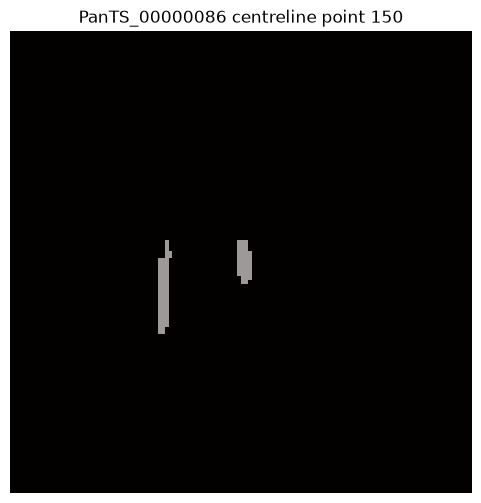

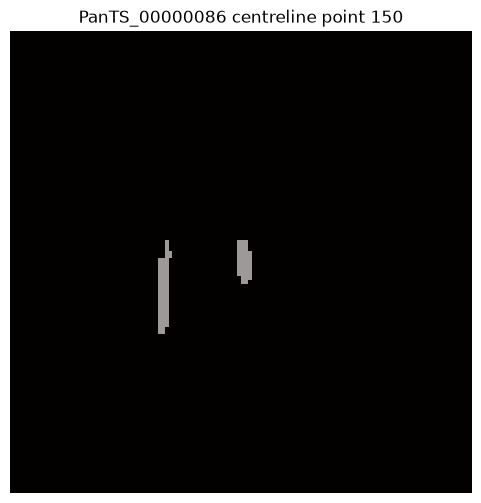

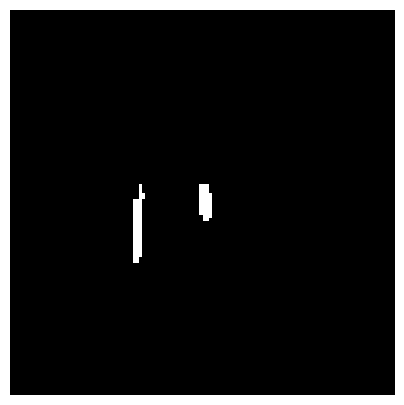

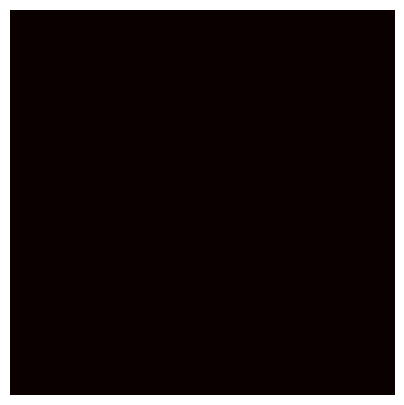

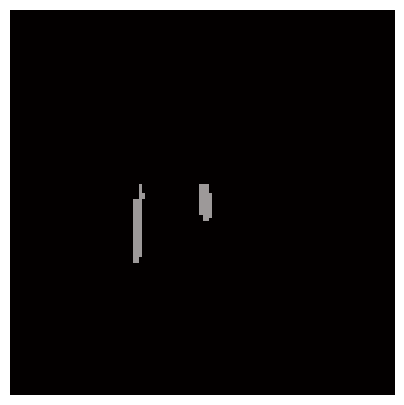

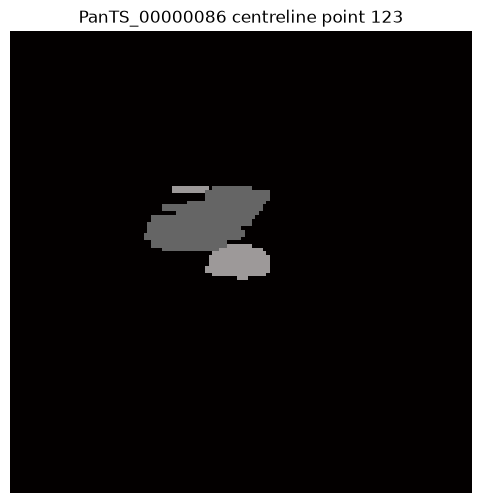

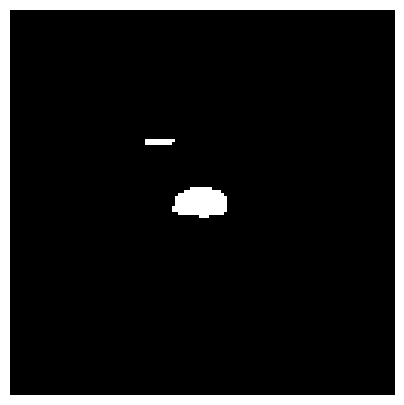

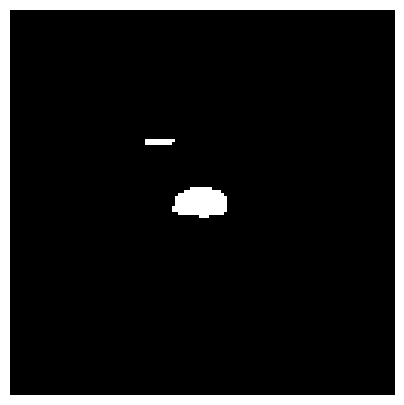

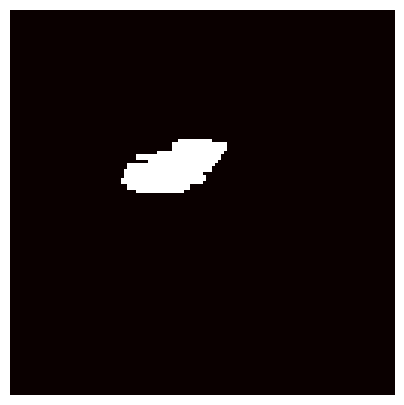

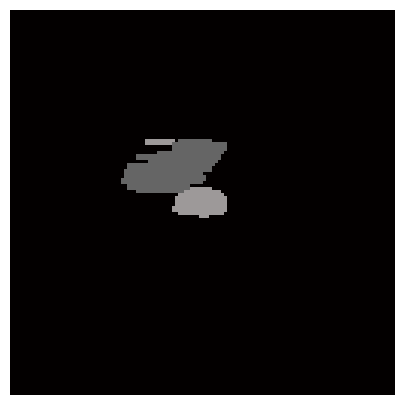

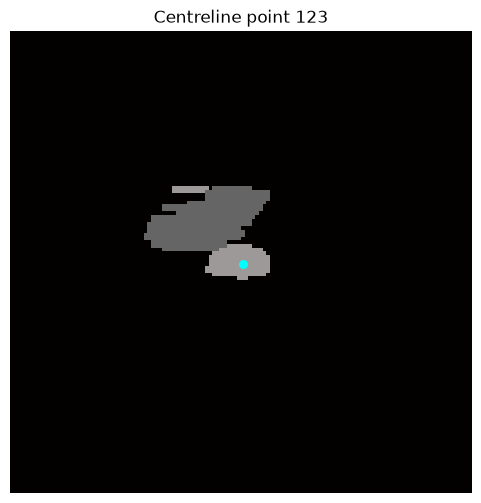

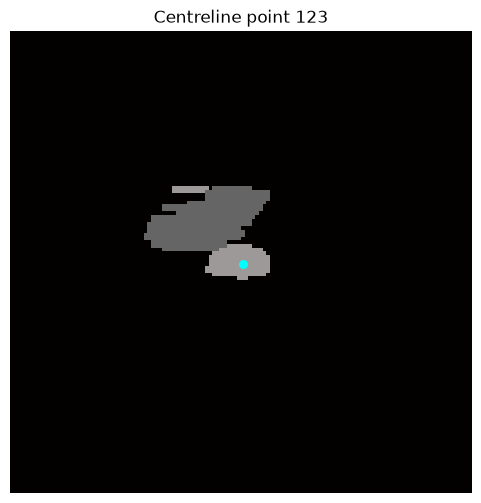

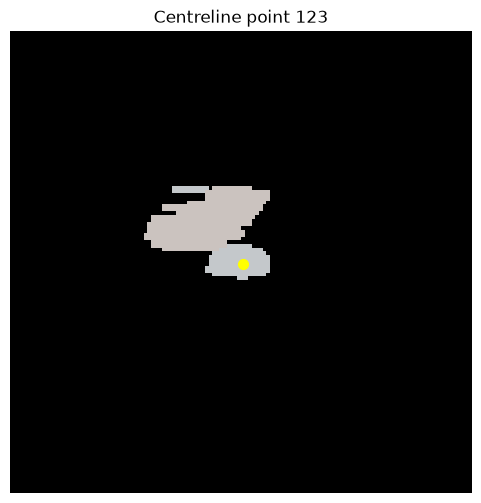

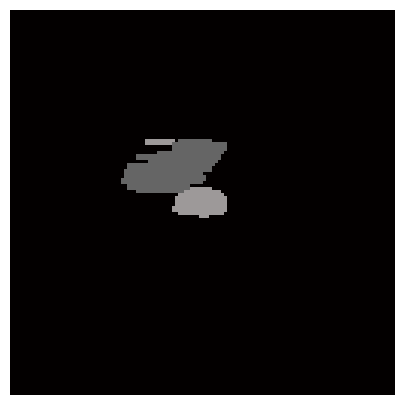

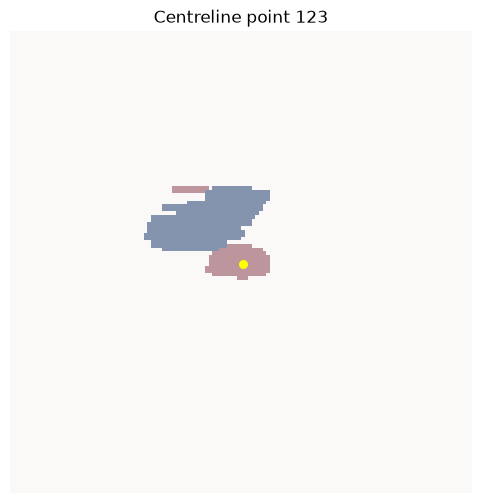

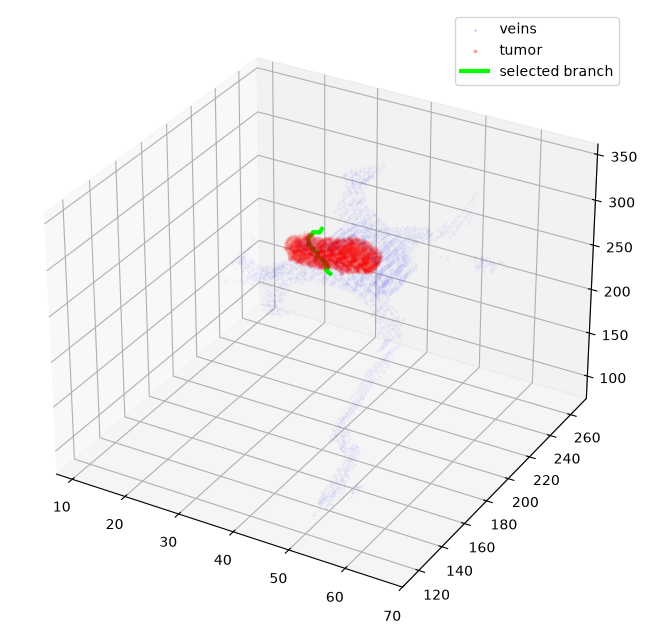

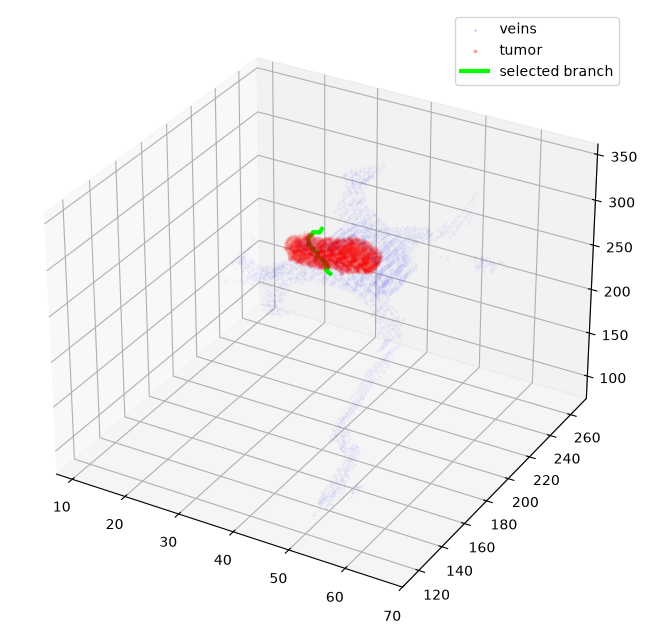

In [103]:
%matplotlib inline

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

CASE_ID = "PanTS_00000086"

VEINS_MASK_PATH = Path(f"../test_data/LabelTr/{CASE_ID}/segmentations/veins.nii.gz")
TUMOR_MASK_PATH = Path(f"../test_data/LabelTr/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")
BRANCH_CSV_PATH = Path(f"../test_results/{CASE_ID}/veins/branch_path.csv")


def load_bin(path):
    nii = nib.load(str(path))
    return (nii.get_fdata() > 0.5).astype(np.uint8)

veins_mask = load_bin(VEINS_MASK_PATH)
tumor_mask = load_bin(TUMOR_MASK_PATH)
branch_coords = np.loadtxt(BRANCH_CSV_PATH, delimiter=",", skiprows=1, usecols=(1,2,3))

def sparse_coords(mask, step=4):
    coords = np.argwhere(mask > 0)
    return coords[::step]

veins_pts = sparse_coords(veins_mask, step=4)
tumor_pts = sparse_coords(tumor_mask, step=2)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(veins_pts[:,2], veins_pts[:,1], veins_pts[:,0], c='blue', s=1, alpha=0.15, label='veins')
ax.scatter(tumor_pts[:,2], tumor_pts[:,1], tumor_pts[:,0], c='red', s=3, alpha=0.3, label='tumor')
ax.plot(branch_coords[:,2], branch_coords[:,1], branch_coords[:,0], c='lime', linewidth=3, label='selected branch')
ax.legend()
plt.show()